- ModernAI的数学精粹与PyTorch求解
    - connecting the dots
    - 形成一个 landscape，尽可能完整的知识图谱

### VI (变分推断)

> 把“积分问题”变成“优化问题”

$$
P(Z|X) = \frac{P(X|Z)P(Z)}{P(X)} =\frac{P(X|Z)P(Z)}{\int P(X|Z)P(Z) dZ}
$$
 
- 在贝叶斯统计中，我们的终极目标是求后验分布 (Posterior) $P(Z|X)$，即在看到数据 $X$ 后，潜在变量 $Z$ 的概率分布。
    - 透过现象（数据 $X$）看本质（隐变量 $Z$）
- 真正的后验分布往往形状极其复杂，而且计算它的分母（Evidence $P(X)$）需要对所有可能的 $Z$ 进行积分：
    - 对于高维空间（例如神经网络的参数空间或复杂模型的隐变量），这个积分是难解的（Intractable）。无法直接算出这个常数。
- 变分推断的思路（The VI Solution）：既然算不出来，我们就猜一个。
    - 我们找一个形状简单、易于计算的分布家族 $Q$（比如高斯分布）。
    - 在这个家族里，找一个参数 $\theta$，使得 $Q_\theta(Z)$ 长得最像真正的 $P(Z|X)$。
    - 定义 reverse KL，最小化这个 RKL
    - 这就把原本痛苦的积分问题，转化为了一个优化问题（调整 $\theta$ 最小化差异）。

### FKL or RKL, and ELBO

$$
KL(Q(z) || P(z|x))
$$

- 标准的变分推断（Variational Inference, VI）中, 使用 RKL。
    - $P(z|x)$ 是真实的（难解的）后验分布，
    - $Q(z)$ 是用来近似的变分分布（Variational Distribution）。
- why RKL not FKL
    - $ KL(Q||P) = \mathbb{E}_{z \sim Q} [\log Q(z) - \log P(z|x)] $
    - 为了计算这个期望，需要对 $z$ 进行采样。在这个公式中，期望是对 $Q$ 求的。因为 $Q$ 是我们自己设定的分布（例如高斯分布），我们可以很容易地对其进行采样和求导。
        - $KL(P||Q) = \mathbb{E}_{z \sim P} [\log P(z|x) - \log Q(z)]$
        - 期望是对真实后验 $P(z|x)$ 求的。这正是问题所在：我们之所以做变分推断，就是因为 $P(z|x)$ 太复杂、无法计算或无法采样。如果我们可以轻易地对 $P(z|x)$ 进行采样来计算这个梯度，我们通常就不需要变分推断了（直接用蒙特卡洛方法即可）。
- RKL vs. FKL 分布性质
    - RKL($KL(Q||P) = \mathbb{E}_{z \sim Q}[\frac{\log Q(z)}{\log P(z|x)}]$): Mode-Seeking, Zero-Forcing
    - FKL($KL(P||Q) = \mathbb{E}_{z \sim P} [\frac{\log P(z|x)}{\log Q(z)}]$): Mean-Seeking, Mass-Covering

$$
\text{Minimize } KL(Q||P) \iff \text{Maximize } \text{ELBO}
$$

- min RKL = max ELBO

$$
\begin{aligned}
KL(Q(z) || P(z|x)) &=\mathbb{E}_{z \sim Q} \left[ \log \frac{Q(z)}{P(z|x)} \right]\\
&= \mathbb{E}_{z \sim Q} \left[ \log \frac{Q(z)}{\frac{P(x, z)}{P(x)}} \right]\\
&=\mathbb{E}_{z \sim Q} \left[ \log Q(z) - \log P(x, z) + \log P(x) \right] \\
&= \underbrace{\mathbb{E}_{z \sim Q} [\log Q(z)] - \mathbb{E}_{z \sim Q} [\log P(x, z)]}_{\text{这一部分即为 -ELBO}} + \underbrace{\mathbb{E}_{z \sim Q} [\log P(x)]}_{\text{常数项}}
\end{aligned}
$$

- $\text{ELBO} = \mathbb{E}_{z \sim Q} [\log P(x, z) - \log Q(z)]$
    - $Q(z)$ (变分分布)： 这是我们自己设定的（比如高斯分布），它的概率密度函数和采样都是已知的、简单的。
    - $P(x, z)$ (联合分布)： 比如生成模型（Prior $\times$ Likelihood，$P(z)\cdot P(x|z)$）。$P(z)$ 是先验（我们设的）。$P(x|z)$ 是似然（我们的网络/模型定义的）。不需要积分！ 我们只需要计算点对点的概率值。
    - ELBO 避开了 $\int P(x,z)dz$，只利用了联合分布 $P(x,z)$。这把一个积分问题（推断）转化为了一个优化问题。
- $KL(Q(z) || P(z|x)) = - \underbrace{\left( \mathbb{E}_{z \sim Q} [\log P(x, z)] - \mathbb{E}_{z \sim Q} [\log Q(z)] \right)}_{\text{ELBO}} + \log P(x)$
- $\log P(x) = \text{ELBO} + KL(Q(z) || P(z|x))$
    -  $\log P(x)$ 是固定的：$P(x) = \int P(x, z) \, dz$ 数据的边际似然（Marginal Likelihood），也叫证据（Evidence）。对于高维空间（例如神经网络的参数空间或复杂模型的隐变量），这个积分是难解的（Intractable）。无法直接算出这个常数。
    -  为了让 $Q(z)$ 尽可能接近 $P(z|x)$（即让 $KL \to 0$），我们必须最大化 ELBO。当 ELBO 被最大化时，KL 散度就被最小化了。

- [Agentic RL] 10 分布的视角理解 LLM 的 SFT 训练和 RL 训练，Forward/Reverse KL，分布与奖励
    - https://www.bilibili.com/video/BV1WvrGBGEbf/ 
    - https://github.com/wdkns/modern_genai_bilibili/blob/main/agentic_rl/sft_rl_fkl_rkl.ipynb

#### 梯度估计 (Gradient Estimation) of ELBO

转化为 ELBO 后，我们就可以利用 Monte Carlo 采样 来估算梯度，从而使用 SGD（随机梯度下降）来优化参数。
$$
\nabla \text{ELBO} \approx \frac{1}{L} \sum_{l=1}^L \nabla (\log P(x, z^{(l)}) - \log Q(z^{(l)}))
$$
- 其中 $z^{(l)}$ 从 $Q(z)$ 中采样。

### VAE

$$
\begin{split}
\text{Loss} &= - \text{ELBO}\\
&= -\mathbb{E}_{q(z|x)} \left[ \log \frac{p(x, z)}{q(z|x)} \right] \\
&=-\mathbb{E}_{q(z|x)} \left[ \log \frac{p(x|z)p(z)}{q(z|x)} \right]\\
&=-\mathbb{E}_{q(z|x)} \left[ \log p(x|z) + \log p(z) - \log q(z|x) \right]\\
&=\underbrace{- \mathbb{E}_{q}[\log p(x|z)]}_{\text{Reconstruction Loss (重构误差)}} + \underbrace{KL(q(z|x) || p(z))}_{\text{KL Divergence (正则项)}}
\end{split}
$$
- Encoder 产生的后验分布 $q(z|x)$， Decoder $p(x|z)$
- Reconstruction Loss (重构误差): $- \mathbb{E}_{q}[\log p(x|z)]$，Decoder $p(x|z)$ 能大概率地还原出原始输入 $x$。如果假设 $p(x|z)$ 是高斯分布，这一项等价于 MSE（均方误差）；如果是伯努利分布，则等价于 Cross Entropy（交叉熵）。
- KL Divergence (正则项): $KL(q(z|x) || p(z))$，Encoder 产生的后验分布 $q(z|x)$ 尽可能接近我们预设的先验分布 $p(z)$（通常是标准正态分布 $\mathcal{N}(0, I)$）。这防止了潜在空间 $z$ 仅仅记住个别数据点，从而保证生成模型的平滑性和生成能力。

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ==========================================
# 1. 定义 VAE 模型
# ==========================================
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        
        # Encoder: 784 (28x28) -> 400 -> 20 (Latent size)
        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, 20) # 输出均值 mu
        self.fc22 = nn.Linear(400, 20) # 输出对数方差 log_var (技巧：预测log方差以保证数值稳定性)
        
        # Decoder: 20 -> 400 -> 784
        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, log_var):
        """
        重参数化技巧的核心函数
        """
        if self.training:
            std = torch.exp(0.5 * log_var) # log_var -> std
            eps = torch.randn_like(std)    # 从标准正态分布采样 epsilon
            return mu + eps * std          # z = mu + sigma * epsilon
        else:
            # 推理时通常直接使用均值
            return mu

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3)) # 输出像素概率 (0-1)

    def forward(self, x):
        # 1. Encode
        mu, log_var = self.encode(x.view(-1, 784))
        # 2. Reparameterize (Sampling)
        z = self.reparameterize(mu, log_var)
        # 3. Decode
        recon_x = self.decode(z)
        return recon_x, mu, log_var

# ==========================================
# 2. 定义 Loss (Negative ELBO)
# ==========================================
def loss_function(recon_x, x, mu, log_var):
    # 第一部分：重构误差 (Reconstruction Loss)
    # 使用 BCE，计算 pixel-wise 的差异并求和
    # reduction='sum' 意味着我们看重整张图的复原，而不仅是平均像素
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')

    # 第二部分：KL 散度 (Regularization)
    # 公式：KL(N(mu, sigma^2) || N(0, 1)) = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    # 这是一个解析解，不需要采样
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    return BCE + KLD, BCE, KLD

In [7]:
# 配置
batch_size = 128
epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 数据加载
train_loader = DataLoader(
    datasets.MNIST('./data', train=True, download=True,
                   transform=transforms.ToTensor()),
    batch_size=batch_size, shuffle=True)

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

model.train()
for epoch in range(epochs):
    train_loss = 0
    train_recon = 0
    train_kld = 0
    
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        
        optimizer.zero_grad()
        
        # Forward Pass
        recon_batch, mu, log_var = model(data)
        
        # 计算 Loss (-ELBO)
        loss, recon, kld = loss_function(recon_batch, data, mu, log_var)
        
        # Backward Pass (这里梯度通过 z 流向 mu, log_var)
        loss.backward()
        
        # Update Weights
        train_loss += loss.item()
        train_recon += recon.item()
        train_kld += kld.item()
        
        optimizer.step()
        
    avg_loss = train_loss / len(train_loader.dataset)
    avg_recon = train_recon / len(train_loader.dataset)
    avg_kld = train_kld / len(train_loader.dataset)

    print(f'Epoch: {epoch+1} | Avg Loss: {avg_loss:.4f} '
          f'(Recon: {avg_recon:.4f}, KL: {avg_kld:.4f})')

Using device: cuda
Epoch: 1 | Avg Loss: 162.6971 (Recon: 146.8137, KL: 15.8834)
Epoch: 2 | Avg Loss: 120.8862 (Recon: 98.3495, KL: 22.5367)
Epoch: 3 | Avg Loss: 114.1532 (Recon: 90.1177, KL: 24.0355)
Epoch: 4 | Avg Loss: 111.2618 (Recon: 86.5972, KL: 24.6646)
Epoch: 5 | Avg Loss: 109.4976 (Recon: 84.5488, KL: 24.9488)
Epoch: 6 | Avg Loss: 108.3264 (Recon: 83.2314, KL: 25.0950)
Epoch: 7 | Avg Loss: 107.5268 (Recon: 82.3152, KL: 25.2116)
Epoch: 8 | Avg Loss: 106.8584 (Recon: 81.5834, KL: 25.2750)
Epoch: 9 | Avg Loss: 106.3547 (Recon: 81.0150, KL: 25.3397)
Epoch: 10 | Avg Loss: 105.9567 (Recon: 80.5755, KL: 25.3812)


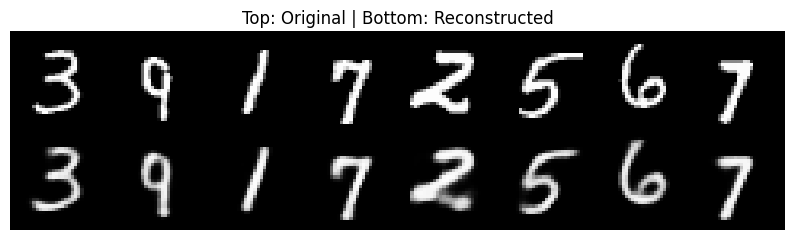

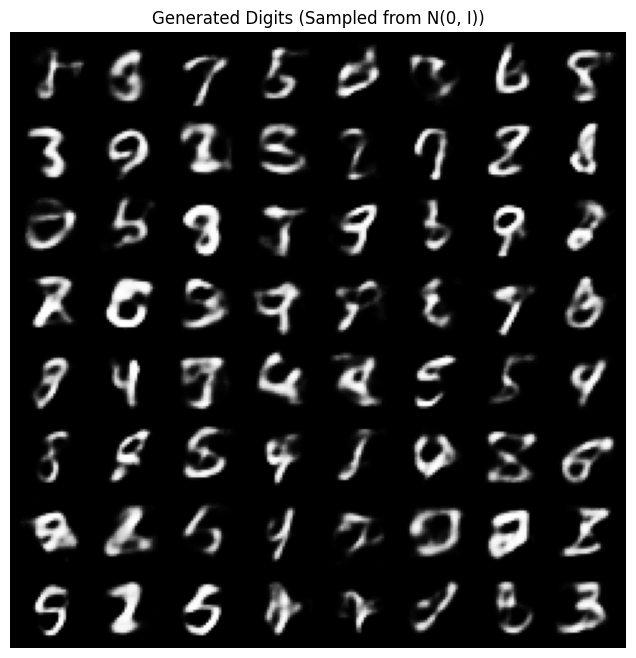

In [8]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

def visualize_results(model, data_loader, device):
    model.eval() # 切换到评估模式
    
    # ===========================
    # 1. 查看重构效果 (Reconstruction)
    # ===========================
    # 获取一个 batch 的真实数据
    data, _ = next(iter(data_loader))
    data = data.to(device)
    
    # 前向传播
    with torch.no_grad():
        recon_batch, _, _ = model(data)
    
    # 取前 8 张图片进行对比
    n = 8
    comparison = torch.cat([data[:n], recon_batch.view(-1, 1, 28, 28)[:n]])
    
    # 制作网格图
    grid = vutils.make_grid(comparison.cpu(), nrow=n, padding=2, normalize=True)
    
    plt.figure(figsize=(10, 3))
    plt.imshow(grid.permute(1, 2, 0)) # (C, H, W) -> (H, W, C)
    plt.title("Top: Original | Bottom: Reconstructed")
    plt.axis('off')

    # ===========================
    # 2. 查看生成效果 (Generation)
    # ===========================
    # 从标准正态分布 N(0, I) 中随机采样 64 个点
    z = torch.randn(64, 20).to(device) # 注意：这里的 20 要对应你模型的 latent_dim
    
    with torch.no_grad():
        generated = model.decode(z).view(-1, 1, 28, 28)
        
    grid_gen = vutils.make_grid(generated.cpu(), nrow=8, padding=2, normalize=True)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(grid_gen.permute(1, 2, 0))
    plt.title("Generated Digits (Sampled from N(0, I))")
    plt.axis('off')

# 调用函数 (假设 model 和 train_loader 已经定义)
visualize_results(model, train_loader, device)

### knowledge distillation

> why FKL here

$$
L_{KD} = KL(P_T(y|x) || P_S(y|x)) = \sum_{i=1}^{C} P_T(y_i|x) \log \frac{P_T(y_i|x)}{P_S(y_i|x)}
$$
- $P_T$ 是已知的：Teacher 模型就在你手里。给定输入 $x$，做一次 Forward Pass，Teacher 吐出的 Softmax 概率向量就是 $P_T$。它是一个具体的、确定的数值向量。
- 积分变成了求和：经典的 KD 是分类任务。积分 $\int$ 变成了对类别 $C$ 的求和 $\sum$。
- 完全可计算：
    - $P_T(y_i|x)$ 是一个具体的数（比如 0.8）。$P_S(y_i|x)$ 是学生模型的输出。
    - 我们不需要“从 Teacher 采样一个类别”，我们可以直接遍历所有类别（比如 ImageNet 1000类，或者 CIFAR 10类），算出精确的 KL 散度值。
- 经典 KD 能用 Forward KL，是因为它的积分域是有限的类别集合，且目标分布 $P$ (Teacher) 是完全透明且可计算的。这与 VI 中面对那个深不可测、无法计算的后验 $P$ 是完全不同的处境。
    - VI: 连续的高维潜变量 $z$ (积分难)
    - KD: 离散的类别标签 $y$ (求和易)
- 在 KD 中，由于 Teacher 是固定的（Detach），$P_T$ 是常数。
    - $KL(P_T || P_S) = \underbrace{-H(P_T)}_{\text{常数}} + \underbrace{H(P_T, P_S)}_{\text{交叉熵}}$
    - 最小化 Forward KL 等价于最小化 Cross Entropy（用 Teacher 的软标签作为 Target）。这就是为什么 KD 代码里通常直接写 `CrossEntropyLoss(student_logits, teacher_probs)`。